# TAZ-Level Hybrid OD Matrix — Superzone Correction Factors on Cellular Structure

Extends the superzone hybrid (step 2) down to the 778 study TAZs. Two routes are examined:

**A. Direct λ-blending of TAZ survey rows** (tested, then rejected): $P^*(j|i) = \lambda_i P^{survey}(j|i) + (1-\lambda_i)P^{prior}(j|i)$ with $\lambda_i = n_i/(n_i+k)$ — evaluated by the same cross-day validation as step 2, with two priors: raw cellular TAZ rows, and a hierarchical prior (superzone hybrid disaggregated through cellular).

**B. Superzone correction factors** (the adopted product): survey information enters only at the superzone level, where it is reliable. For TAZ $i \in A$ and $j \in B$, compute the superzone correction
$$ R_{AB} = \frac{P^*(B|A)}{P^{cell}(B|A)} $$
from the calibrated superzone hybrid, scale the individual cellular OD cells
$$ \tilde C_{ij} = C_{ij}\, R_{AB}, $$
and row-normalize to obtain $\tilde P(j|i)$. This keeps each TAZ's own cellular destination profile (within-superzone heterogeneity survives) while matching the calibrated superzone-to-superzone pattern.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
RED, MID = '#e34948', '#f0efec'
INK, INK2 = '#0b0b0b', '#52514e'

## 1. Inputs — TAZ-level survey days, cellular matrix, superzone machinery

In [2]:
df = pd.read_csv('Input/Matrices/ACTIVITIES_DEC18_corrected.csv')
weights = pd.read_csv('Input/Matrices/households_with_weights.csv')[['HHID', 'wf_new']]
df = df.merge(weights, on='HHID', how='left', validate='many_to_one')

keys_raw = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
keys_sz = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna(subset=['TAZ_NUMBER'])
keys_sz['TAZ_NUMBER'] = keys_sz['TAZ_NUMBER'].astype(int)
taz_to_sz = keys_sz.set_index('TAZ_NUMBER')['SZ_NEW'].to_dict()

def am_peak_trips(df_day):
    d = df_day.sort_values(by=['INDIVID', 'tourID', 'ACT_ID'])
    d['origin'] = d.groupby(['INDIVID', 'tourID'])['taz'].shift(1)
    d['destination'] = d['taz']
    d['StartTime'] = pd.to_datetime(d['StartTime'], dayfirst=True)
    d['EndTime'] = pd.to_datetime(d['EndTime'], dayfirst=True)
    d['leaving_time'] = pd.to_datetime(np.where(d['mainActivity'] == 'Home', d['EndTime'], d['StartTime']))
    mask = (d['leaving_time'].dt.hour >= 6) & (d['leaving_time'].dt.hour < 9)
    f = d[mask].dropna(subset=['origin', 'destination'])
    # model-area trips only: both ends must have a real TAZ; Default arrival = no reported travel
    return f[(f['origin'] != 0) & (f['destination'] != 0) & (f['MODE_NAME'] != 'Default')]

t10 = am_peak_trips(df[df['ACT_DAY'] == 10])
t20 = am_peak_trips(df[df['ACT_DAY'] == 20])

cellular = pd.read_csv('Input/Matrices/AvgDayHourlyTrips201819_1270_weekday_v1.csv')[['fromZone', 'ToZone', 'h6', 'h7', 'h8']]
keys = keys_raw[['TAZ_1270', 'TAZ_NUMBER']].dropna(subset=['TAZ_NUMBER'])
keys['TAZ_NUMBER'] = keys['TAZ_NUMBER'].astype(int)
keys = keys.drop_duplicates(subset=['TAZ_NUMBER'])
c = cellular.merge(keys.rename(columns={'TAZ_1270': 'fromZone', 'TAZ_NUMBER': 'fromTaz'}), on='fromZone')
c = c.merge(keys.rename(columns={'TAZ_1270': 'ToZone', 'TAZ_NUMBER': 'ToTaz'}), on='ToZone')
cell_taz = c.groupby(['fromTaz', 'ToTaz'])[['h6', 'h7', 'h8']].sum().sum(axis=1).unstack().fillna(0)
TAZ = cell_taz.index
P_cell_taz = cell_taz.div(cell_taz.sum(axis=1), axis=0).fillna(0)

sz_of = pd.Series({t: taz_to_sz[t] for t in TAZ})
SZ = sorted(sz_of.unique())
sz_idx = {s: i for i, s in enumerate(SZ)}
col_sz = np.array([sz_idx[sz_of[t]] for t in TAZ])
M = np.zeros((len(TAZ), len(SZ)))
M[np.arange(len(TAZ)), col_sz] = 1   # TAZ -> SZ indicator

def taz_mats(t):
    t = t[t['origin'].isin(TAZ) & t['destination'].isin(TAZ)]
    W = t.groupby(['origin', 'destination'])['wf_new'].sum().unstack().fillna(0).reindex(index=TAZ, columns=TAZ, fill_value=0)
    N = t.groupby(['origin', 'destination']).size().unstack().fillna(0).reindex(index=TAZ, columns=TAZ, fill_value=0)
    return W, N

W10, N10 = taz_mats(t10)
W20, N20 = taz_mats(t20)
n10, n20 = N10.sum(axis=1), N20.sum(axis=1)
P10 = W10.div(W10.sum(axis=1), axis=0).fillna(0)
P20 = W20.div(W20.sum(axis=1), axis=0).fillna(0)

n_pool = n10 + n20
print(f"trips inside the 778-TAZ system: day 10 = {n10.sum():.0f}, day 20 = {n20.sum():.0f}")
print(f"observations per origin TAZ (day 10): median {n10.median():.0f}, mean {n10.mean():.1f}, "
      f"origins with zero trips: {(n10 == 0).sum()} of {len(TAZ)}")
print(f"pooled: median {n_pool.median():.0f}, zero-origins {(n_pool == 0).sum()}")

trips inside the 778-TAZ system: day 10 = 14286, day 20 = 14053
observations per origin TAZ (day 10): median 11, mean 18.4, origins with zero trips: 125 of 778
pooled: median 23, zero-origins 102


In [3]:
# superzone-level machinery (as in step 2)
def sz_from_taz(Wt):
    return pd.DataFrame(M.T @ Wt.values @ M, index=SZ, columns=SZ)

cell_sz = sz_from_taz(cell_taz)
P_cell_sz = cell_sz.div(cell_sz.sum(axis=1), axis=0).fillna(0)

def sz_prob_and_n(Wd, Nd):
    Wsz, Nsz = sz_from_taz(Wd), sz_from_taz(Nd)
    return Wsz.div(Wsz.sum(axis=1), axis=0).fillna(0), Nsz.sum(axis=1)

P10_sz, n10_sz = sz_prob_and_n(W10, N10)
P20_sz, n20_sz = sz_prob_and_n(W20, N20)

def sz_hybrid(P_s_sz, n_sz, k):
    lam = (n_sz / (n_sz + k)).values
    return P_s_sz.mul(lam, axis=0).add(P_cell_sz.mul(1 - lam, axis=0))

## 2. Route A — direct λ-blending, tested by cross-day validation

Priors: raw cellular rows, and a hierarchical prior (day-specific superzone hybrid at $k_{SZ}=2$, disaggregated through each TAZ's cellular within-superzone destination shares). Origins with $n_i = 0$ always receive the prior row ($\lambda_i := 0$), at every $k$, so all $k$ are compared on identical rows.

In [4]:
inflow = cell_taz.sum(axis=0).values
inflow_share = np.zeros(len(TAZ))
for s in range(len(SZ)):
    m = col_sz == s
    tot = inflow[m].sum()
    inflow_share[m] = inflow[m] / tot if tot > 0 else 1.0 / m.sum()

def downscale(P_sz_hyb):
    '''hierarchical prior: SZ pattern from the hybrid, within-SZ allocation from cellular rows'''
    Pc = P_cell_taz.values
    Sx = (Pc @ M)[:, col_sz]
    alloc = np.where(Sx > 0, Pc / np.where(Sx == 0, 1, Sx), inflow_share[None, :])
    sz_w = P_sz_hyb.values[col_sz][:, col_sz]
    Pr = alloc * sz_w
    rs = Pr.sum(axis=1, keepdims=True)
    return pd.DataFrame(np.where(rs > 0, Pr / rs, 0), index=TAZ, columns=TAZ)

prior_h10 = downscale(sz_hybrid(P10_sz, n10_sz, 2))
prior_h20 = downscale(sz_hybrid(P20_sz, n20_sz, 2))

def blend(P_s, n, k, prior):
    lam = np.where(n.values > 0, n.values / (n.values + k), 0.0) if np.isfinite(k) else np.zeros(len(n))
    return pd.DataFrame(P_s.values * lam[:, None] + prior.values * (1 - lam[:, None]), index=TAZ, columns=TAZ)

def mean_jsd(P_pred, P_t):
    Pp, Pt_ = P_pred.values, P_t.values
    vals = []
    for i in range(len(TAZ)):
        p, q = Pp[i], Pt_[i]
        if p.sum() <= 0 or q.sum() <= 0:
            continue
        p, q = p / p.sum(), q / q.sum()
        m = (p + q) / 2
        kl = lambda a, b: np.sum(a[a > 0] * np.log2(a[a > 0] / b[a > 0]))
        vals.append(0.5 * kl(p, m) + 0.5 * kl(q, m))
    return float(np.mean(vals))

ks = [0, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 200, 500, np.inf]
cv = []
for k in ks:
    cv.append({'k': k,
        'cellular prior': (mean_jsd(blend(P10, n10, k, P_cell_taz), P20) + mean_jsd(blend(P20, n20, k, P_cell_taz), P10)) / 2,
        'hierarchical prior': (mean_jsd(blend(P10, n10, k, prior_h10), P20) + mean_jsd(blend(P20, n20, k, prior_h20), P10)) / 2})
cv = pd.DataFrame(cv).set_index('k')
cv.round(4)

/tmp/ipykernel_2065/2548604065.py:22: RuntimeWarning: invalid value encountered in divide
  lam = np.where(n.values > 0, n.values / (n.values + k), 0.0) if np.isfinite(k) else np.zeros(len(n))


,cellular prior,hierarchical prior
k,,
0.0,0.3036,0.3015
1.0,0.3226,0.3126
2.0,0.3397,0.3253
3.0,0.3546,0.3366
5.0,0.3795,0.3561
7.0,0.4000,0.3723
10.0,0.4254,0.3925
15.0,0.4585,0.4187
20.0,0.4842,0.4392


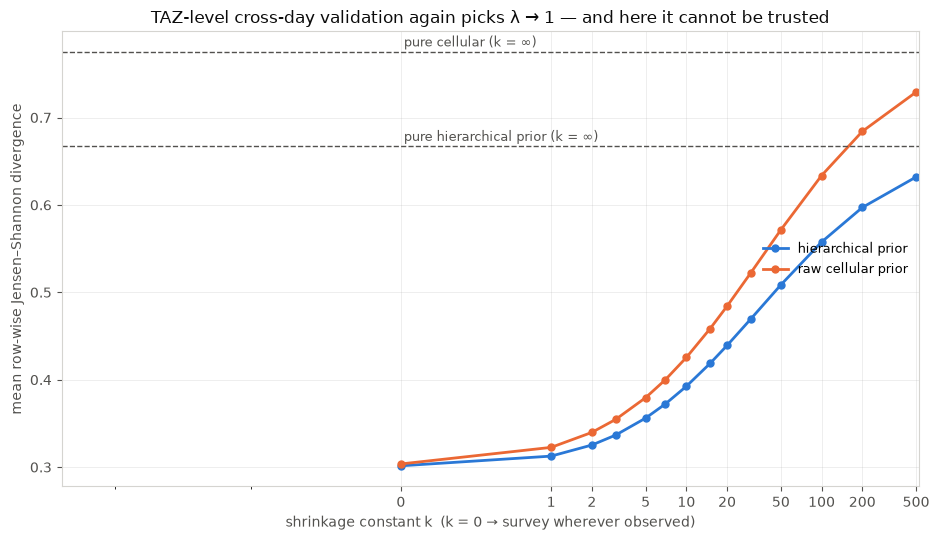

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 5.5), facecolor='white')
finite = cv.index[np.isfinite(cv.index)]
ax.plot(finite, cv.loc[finite, 'hierarchical prior'], color=BLUE, linewidth=2, marker='o', markersize=5, label='hierarchical prior')
ax.plot(finite, cv.loc[finite, 'cellular prior'], color=ORANGE, linewidth=2, marker='o', markersize=5, label='raw cellular prior')
for name, y in [('pure hierarchical prior (k = ∞)', cv.loc[np.inf, 'hierarchical prior']),
                ('pure cellular (k = ∞)', cv.loc[np.inf, 'cellular prior'])]:
    ax.axhline(y, color=INK2, linestyle='--', linewidth=1)
    ax.annotate(name, xy=(0.02, y), xytext=(0, 4), textcoords='offset points', color=INK2, fontsize=9)
ax.set_xscale('symlog', linthresh=1)
ax.set_xticks([0, 1, 2, 5, 10, 20, 50, 100, 200, 500])
ax.set_xticklabels(['0', '1', '2', '5', '10', '20', '50', '100', '200', '500'])
ax.set_xlabel('shrinkage constant k  (k = 0 → survey wherever observed)', color=INK2)
ax.set_ylabel('mean row-wise Jensen–Shannon divergence', color=INK2)
ax.set_title('TAZ-level cross-day validation again picks λ → 1 — and here it cannot be trusted', color=INK, fontsize=12)
ax.grid(True, alpha=0.25, linewidth=0.6)
for s in ax.spines.values(): s.set_color('#d5d4d0')
ax.tick_params(colors=INK2)
ax.legend(frameon=False, fontsize=9, loc='center right')
plt.tight_layout()
plt.savefig('Output/figures/hybrid_taz_cv_curve.png', dpi=150, bbox_inches='tight')
plt.show()

**Why Route A's validation verdict is disqualified.** The curve again rises monotonically from $k=0$: cross-day validation wants pure survey wherever a survey row exists. But at TAZ resolution an origin row is a *handful of specific households* (median 11 trips), and the same people travel to the same workplaces on both survey days — Day 20 largely repeats Day 10's exact TAZ pairs. The validation is therefore measuring **within-person habit persistence**, not population accuracy, and it structurally selects $\lambda \to 1$. Unlike at superzone level (where rows pool hundreds of households), this makes CV-based calibration of $\lambda$ untrustworthy at TAZ level — which motivates Route B, where sparse TAZ survey rows are never used directly.

## 3. Route B (adopted) — superzone correction factors on cellular cells

$R_{AB} = P^*(B|A)/P^{cell}(B|A)$ from the pooled superzone hybrid; $\tilde C_{ij} = C_{ij} R_{AB}$; rows normalized. Built at $k_{SZ}=2$ (the step-2 calibration) and at $k_{SZ}=100$ as the variant that keeps a substantial cellular floor.

In [6]:
W_pool_sz = sz_from_taz(W10 + W20)
P_pool_sz = W_pool_sz.div(W_pool_sz.sum(axis=1), axis=0).fillna(0)
n_pool_sz = n10_sz + n20_sz

def correction_disagg(k_sz):
    P_star = sz_hybrid(P_pool_sz, n_pool_sz, k_sz)
    R = np.where(P_cell_sz.values > 0,
                 P_star.values / np.where(P_cell_sz.values == 0, 1, P_cell_sz.values), 1.0)
    C_tilde = cell_taz.values * R[col_sz][:, col_sz]
    rs = C_tilde.sum(axis=1, keepdims=True)
    P_tilde = np.where(rs > 0, C_tilde / rs, 0)
    return (pd.DataFrame(P_tilde, index=TAZ, columns=TAZ),
            pd.DataFrame(R, index=SZ, columns=SZ))

P_taz_hybrid, R_k2 = correction_disagg(2)
P_taz_hybrid_k100, R_k100 = correction_disagg(100)

for name, R in [('k_sz=2', R_k2), ('k_sz=100', R_k100)]:
    diag = np.diag(R.values)
    off = R.values[~np.eye(len(SZ), dtype=bool)]
    print(f"R_AB at {name}:  diagonal median {np.median(diag):.2f} (max {diag.max():.1f})   "
          f"off-diagonal median {np.median(off):.3f}, share < 1: {(off < 1).mean():.0%}")
zero_pairs = (sz_from_taz(N10 + N20).values[~np.eye(len(SZ), dtype=bool)] == 0).mean()
print(f"off-diagonal SZ pairs with zero pooled survey observations: {zero_pairs:.0%}")

R_AB at k_sz=2:  diagonal median 2.21 (max 13.7)   off-diagonal median 0.095, share < 1: 90%
R_AB at k_sz=100:  diagonal median 2.07 (max 11.9)   off-diagonal median 0.264, share < 1: 90%
off-diagonal SZ pairs with zero pooled survey observations: 45%


In [7]:
# how well does the corrected matrix predict a held-out survey day, using NO TAZ-level survey data?
def corr_disagg_from(P_s_sz, n_sz, k_sz=2):
    P_star = sz_hybrid(P_s_sz, n_sz, k_sz)
    R = np.where(P_cell_sz.values > 0, P_star.values / np.where(P_cell_sz.values == 0, 1, P_cell_sz.values), 1.0)
    Ct = cell_taz.values * R[col_sz][:, col_sz]
    rs = Ct.sum(axis=1, keepdims=True)
    return pd.DataFrame(np.where(rs > 0, Ct / rs, 0), index=TAZ, columns=TAZ)

pt10 = corr_disagg_from(P10_sz, n10_sz)
pt20 = corr_disagg_from(P20_sz, n20_sz)
comparison = pd.Series({
    'raw cellular': (mean_jsd(P_cell_taz, P20) + mean_jsd(P_cell_taz, P10)) / 2,
    'hierarchical downscale': (mean_jsd(prior_h10, P20) + mean_jsd(prior_h20, P10)) / 2,
    'correction-factor matrix': (mean_jsd(pt10, P20) + mean_jsd(pt20, P10)) / 2,
}, name='mean row JSD vs held-out day')
comparison.round(4).to_frame()

,mean row JSD vs held-out day
raw cellular,0.7750
hierarchical downscale,0.6669
correction-factor matrix,0.6713


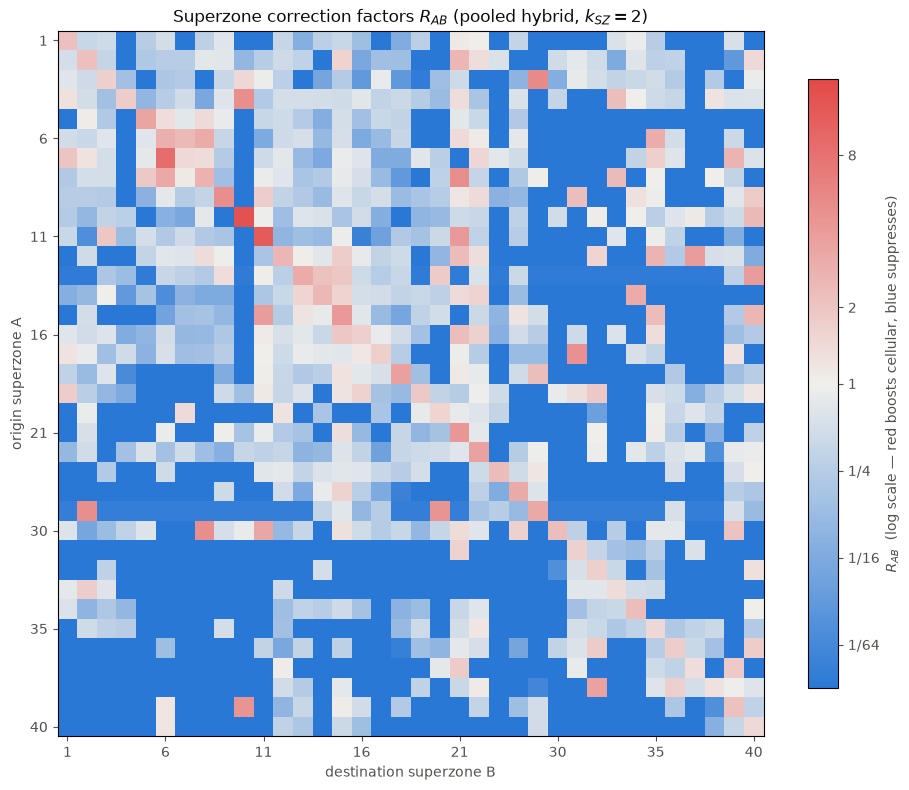

In [8]:
cmap = mcolors.LinearSegmentedColormap.from_list('corr', [BLUE, MID, RED])
logR = np.log2(np.clip(R_k2.values, 2**-7, None))
norm = mcolors.TwoSlopeNorm(vmin=-7, vcenter=0, vmax=4)

fig, ax = plt.subplots(figsize=(9.6, 8.2), facecolor='white')
im = ax.imshow(logR, cmap=cmap, norm=norm)
ax.set_title('Superzone correction factors $R_{AB}$ (pooled hybrid, $k_{SZ}=2$)', color=INK, fontsize=12)
ax.set_xlabel('destination superzone B', color=INK2)
ax.set_ylabel('origin superzone A', color=INK2)
ticks = range(0, len(SZ), 5)
ax.set_xticks(list(ticks)); ax.set_xticklabels([SZ[i] for i in ticks])
ax.set_yticks(list(ticks)); ax.set_yticklabels([SZ[i] for i in ticks])
ax.tick_params(colors=INK2)
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_ticks([np.log2(v) for v in [1/64, 1/16, 1/4, 1, 2, 8]])
cb.set_ticklabels(['1/64', '1/16', '1/4', '1', '2', '8'])
cb.set_label('$R_{AB}$  (log scale — red boosts cellular, blue suppresses)', color=INK2)
cb.ax.tick_params(colors=INK2)
plt.tight_layout()
plt.savefig('Output/figures/correction_factors_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
P_taz_hybrid.to_csv('Output/hybrid_taz_prob.csv', float_format='%.6g')
P_taz_hybrid_k100.to_csv('Output/hybrid_taz_prob_k100.csv', float_format='%.6g')
R_k2.to_csv('Output/sz_correction_factors.csv', float_format='%.6g')
R_k100.to_csv('Output/sz_correction_factors_k100.csv', float_format='%.6g')
cv.to_csv('Output/hybrid_taz_cv_results.csv')
print("saved: hybrid_taz_prob.csv, hybrid_taz_prob_k100.csv, sz_correction_factors.csv, "
      "sz_correction_factors_k100.csv, hybrid_taz_cv_results.csv")
print(f"rows summing to 1 in hybrid_taz_prob: {np.isclose(P_taz_hybrid.sum(axis=1), 1).sum()} of {len(TAZ)}")

saved: hybrid_taz_prob.csv, hybrid_taz_prob_k100.csv, sz_correction_factors.csv, sz_correction_factors_k100.csv, hybrid_taz_cv_results.csv
rows summing to 1 in hybrid_taz_prob: 778 of 778


## 5. Trips matrix and sub-area extraction

The hybrid is a row-probability matrix; converting it to trips needs an origin-volume
vector $T_i$ (expanded AM-peak departures per TAZ). Consistent with the rest of the
construction — survey sets the scale where it is reliable, cellular supplies within-superzone
structure:

$$ T_i = V_{A(i)} \cdot \frac{o_i^{cell}}{\sum_{i' \in A(i)} o_{i'}^{cell}}, \qquad
   \text{Trips}_{ij} = T_i \cdot \tilde P(j|i) $$

where $V_A$ is the average-weekday expanded survey departure total of superzone $A$
(≈ 2.28M trips over all zones, as in `hybrid_sz_trips.csv`) and $o_i^{cell}$ is TAZ $i$'s
cellular outflow. Origin totals therefore match the superzone hybrid trips exactly at
superzone level; the within-superzone split inherits the cellular replication caveat.

In [10]:
# origin volumes: survey superzone departures (avg weekday) split by cellular outflow shares
vol_sz = pd.Series(M.T @ ((W10.sum(axis=1) + W20.sum(axis=1)) / 2).values, index=SZ)
cell_out = cell_taz.sum(axis=1).values
share = np.zeros(len(TAZ))
for s_i, s in enumerate(SZ):
    m = col_sz == s_i
    tot = cell_out[m].sum()
    share[m] = cell_out[m] / tot if tot > 0 else 1.0 / m.sum()
T_origin = vol_sz.values[col_sz] * share

T_hybrid_taz = P_taz_hybrid.mul(T_origin, axis=0)
print(f"hybrid TAZ trips total (avg weekday AM peak): {T_hybrid_taz.sum().sum():,.0f}")

# origin totals aggregated back to superzones must equal the superzone volumes exactly
sz_check = pd.Series(M.T @ T_hybrid_taz.sum(axis=1).values, index=SZ)
assert np.allclose(sz_check, vol_sz), "superzone origin totals do not match"
print("superzone origin totals match the survey expanded departures — OK")

T_hybrid_taz.to_csv('Output/hybrid_taz_trips.csv', float_format='%.6g')
print("saved: Output/hybrid_taz_trips.csv (778x778)")

hybrid TAZ trips total (avg weekday AM peak): 2,152,928
superzone origin totals match the survey expanded departures — OK


saved: Output/hybrid_taz_trips.csv (778x778)


In [11]:
# 119-TAZ sub-area extraction, same layout and order as Output/submatrices/
SUB_TAZ = [1520,2402,2412,2420,2405,2421,2404,2426,2413,2407,2406,2403,2415,1521,1524,2401,2408,
           1518,1519,1517,1516,1515,1514,1512,1510,1511,1501,1502,1215,1522,1503,1509,1508,1505,
           1506,1504,1302,1304,1507,1306,1225,1307,1312,1303,1308,1313,1309,1216,1217,1311,1310,
           1305,1401,1417,1408,1409,1726,1727,1218,1719,1212,1224,1214,1205,1213,1221,1220,1219,
           1211,1513,1523,1210,1209,1203,715,722,918,917,919,920,922,912,923,913,911,914,902,903,
           904,714,709,905,1222,408,422,423,409,1002,1005,1102,420,2101,1921,1906,2005,2001,2012,
           1904,2002,2010,2009,2007,2004,2008,2003,1924,1920,1801,1208]
sub = T_hybrid_taz.reindex(index=SUB_TAZ, columns=SUB_TAZ, fill_value=0.0)
sub.index.name = 'origin'
sub.to_csv('Output/submatrices/hybrid_taz_trips.csv', float_format='%.6g')
print(f"saved: Output/submatrices/hybrid_taz_trips.csv (119x119)")
print(f"trips with both ends inside the sub-area: {sub.sum().sum():,.0f} "
      f"({sub.sum().sum() / T_hybrid_taz.sum().sum():.1%} of the hybrid total)")

saved: Output/submatrices/hybrid_taz_trips.csv (119x119)
trips with both ends inside the sub-area: 121,169 (5.6% of the hybrid total)


## 6. Findings

**1. The adopted TAZ matrix is corrected cellular, calibrated by the survey at superzone scale.** $\tilde C_{ij} = C_{ij} R_{AB}$ preserves each TAZ's own cellular destination profile while matching the calibrated superzone pattern. As a predictor of a held-out survey day it improves on raw cellular by ~13% mean JSD (0.671 vs 0.775) *without using any TAZ-level survey information*, performing on par with the hierarchical downscale (0.667).

**2. Direct λ-blending at TAZ level was tested and rejected.** Cross-day validation again selects $k=0$ monotonically — but at this resolution that verdict reflects within-person habit persistence (the same households repeating the same TAZ-to-TAZ commutes on both days), not population accuracy. The CV that was informative at superzone level is structurally biased at TAZ level.

**3. The correction factors are dominated by the intra-zone divergence and survey sparsity.** Diagonal $R_{AA}$ has median ≈ 2.2 (max 13.7) — intra-superzone flows boosted, following the survey's 72% self-containment — while 45% of off-diagonal superzone pairs have zero pooled survey observations, driving their $R_{AB}$ toward the small shrinkage floor. At $k_{SZ}=2$ the off-diagonal median is ≈ 0.10 — the correction largely transfers the survey's pattern *and its sparsity*. The $k_{SZ}=100$ variant (off-diagonal median ≈ 0.26) keeps a larger cellular floor on survey-unobserved pairs and is the safer choice if downstream use requires coverage of rare OD pairs.

**4. Choose by use case.** `hybrid_taz_prob.csv` ($k_{SZ}=2$) follows the survey wherever it speaks; `hybrid_taz_prob_k100.csv` trades fidelity to the survey pattern for robustness on unobserved pairs. Both inherit the open intra-zone question from step 1 — the diagonal boost is exactly where survey and cellular measurement disagree — and the cellular replication caveat (1270→778 mapping) applies to the within-superzone allocation.